1. Importation des modules à utiliser

In [1]:
import voice_controle as voice
import matplotlib.pyplot as plt
import numpy as np

4. Bruits

In [2]:
t = np.linspace(0, 0.5, 5000) # temps de simulation
BRUIT = voice.bruit(t)

2. Microphone dynamique

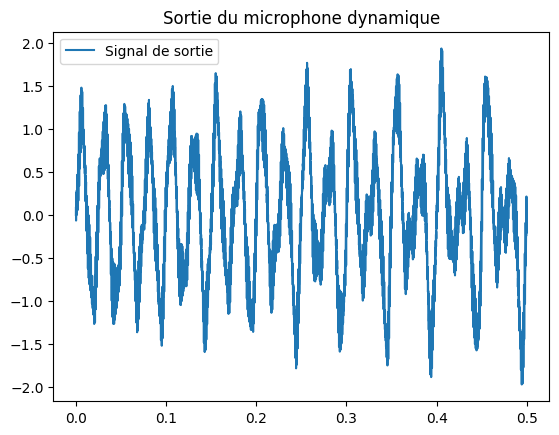

In [3]:
resistance1 = 100 # résistance du microphone dynamique en ohm
frequency1 = 20 # fréquence fondamentale pour ce microphone
amplitudes = (
        lambda x : np.sin(x),
        lambda x : np.cos(x),
        lambda x : np.cos(x) * np.sin(x)
    )

micro_dynamique = voice.MicroDynamique(resistance1, frequency1, amplitudes)
sortie_dynamique = micro_dynamique.get_output(t, BRUIT)

plt.plot(t, sortie_dynamique, label="Signal de sortie")
plt.title("Sortie du microphone dynamique")
plt.legend()
plt.show()

3. Microphone statique

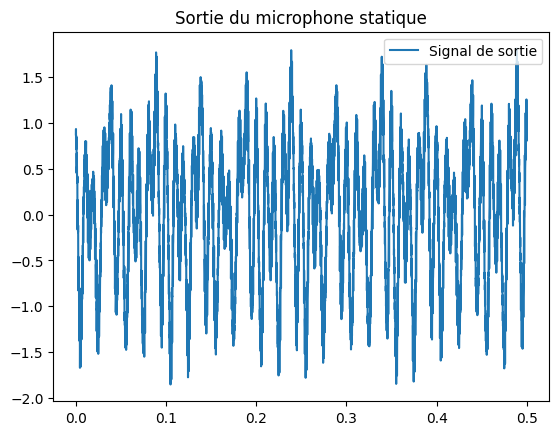

In [4]:
resistance2 = 100
tension_fantome = 48 # Tension d'alimentation du microphone
frequency2 = 20
capacities = (5e-7, 4e-7, 2e-7, 1e-7, 2.5e-7) # Capacités pour chaque harmonique
phases = (np.pi / 2, np.pi, 0, 0, 0)          # Déphasage de chaque harmonique

micro_statique = voice.MicroStatique(resistance2, tension_fantome,
                                     frequency2, capacities, phases)
sortie_statique = micro_statique.get_output(t, BRUIT)

plt.plot(t, sortie_statique, label="Signal de sortie")
plt.title("Sortie du microphone statique")
plt.legend()
plt.show()

5. Amplificateur

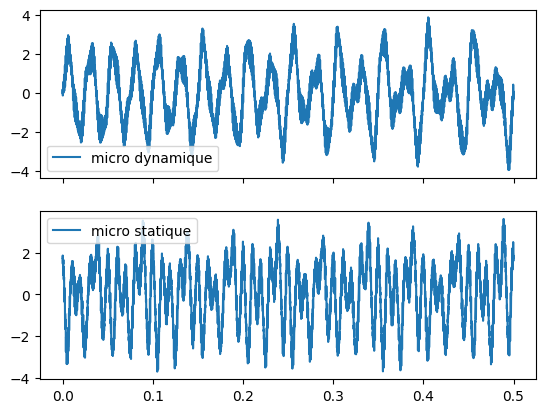

In [5]:
resistance3 = 1 # Prémière resistance de l'amplificateur
resistance4 = 1 # Deuxième resistance de l'amplificateur
amplificateur = voice.Amplificateur(resistance3, resistance4)

sortie_ampli_microD = amplificateur.get_output(sortie_dynamique)
sortie_ampli_microS = amplificateur.get_output(sortie_statique)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t, sortie_ampli_microD, label="micro dynamique") ; ax1.legend()
ax2.plot(t, sortie_ampli_microS, label="micro statique") ; ax2.legend()
plt.show()

6. Filtre passe-bas d'ordre 1 (RC)

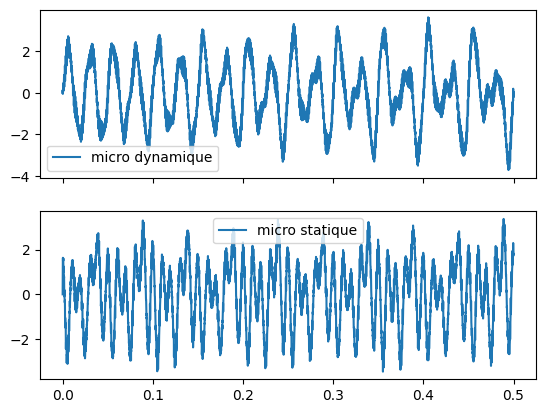

In [6]:
capacity1 = 500e-6 # capacité du filtre RC
frequency_cutoff = 2000 # fréquence de coupure
filtre_rc = voice.FiltrePasseBasOrdre1(capacity1, frequency_cutoff)

sortie_filtre_rcD = filtre_rc.get_output(sortie_ampli_microD, t)
sortie_filtre_rcS = filtre_rc.get_output(sortie_ampli_microS, t)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t, sortie_filtre_rcD, label="micro dynamique") ; ax1.legend()
ax2.plot(t, sortie_filtre_rcS, label="micro statique") ; ax2.legend()
plt.show()

7. Filtre passe-bas d'ordre 2 (Cellule de Sallen et Key)

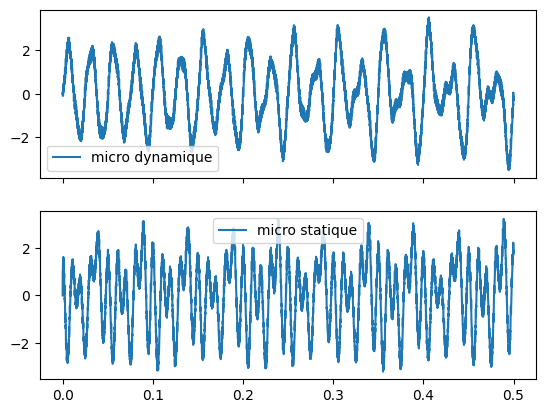

In [7]:
capacity2 = 500e-6 # capacité N°2 de la cellule de Sallen et Key
quality_factor = 0.5 # facteur de qualité de la cellule
frequency_resonant = 2 * np.pi * 1200 # fréquence de résonance angulaire

filtre_ordre2 = voice.CelluleOrdre2(capacity2, quality_factor, frequency_resonant)

sortie_filtre_2D = filtre_ordre2.get_output(sortie_ampli_microD, t)
sortie_filtre_2S = filtre_ordre2.get_output(sortie_ampli_microS, t)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t, sortie_filtre_2D, label="micro dynamique") ; ax1.legend()
ax2.plot(t, sortie_filtre_2S, label="micro statique") ; ax2.legend()
plt.show()